In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, top_k_accuracy_score, f1_score
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
from google.colab import drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

print("Loading data...")
csv_path = "/content/drive/MyDrive/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(csv_path)
print(f"Initial Dataset Shape: {df.shape}")

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
Initial Dataset Shape: (246945, 378)


In [16]:
target_col = "diseases"
feature_cols = [c for c in df.columns if c != target_col]

# 1. Memory Optimization
X = df[feature_cols].astype(np.uint8)
y_raw = df[target_col]

# 2. Drop Zero-Variance Features
nunique = X.nunique()
useless_cols = nunique[nunique <= 1].index.tolist()
if useless_cols:
    X = X.drop(columns=useless_cols)

# 3. Drop Exact Duplicates
combined = X.copy()
combined['__target__'] = y_raw
dup_mask = combined.duplicated(keep='first').values
X = X[~dup_mask].reset_index(drop=True)
y_raw = y_raw[~dup_mask].reset_index(drop=True)

# 4. Drop Rare Classes (<2 samples)
class_counts = y_raw.value_counts()
rare_classes = class_counts[class_counts < 2].index
if len(rare_classes) > 0:
    mask = ~y_raw.isin(rare_classes)
    X = X[mask].reset_index(drop=True)
    y_raw = y_raw[mask].reset_index(drop=True)

# 5. Perfect Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
new_num_classes = len(le.classes_)

print(f"Cleaned Data -> Rows: {X.shape[0]}, Features: {X.shape[1]}, Valid Classes: {new_num_classes}")

Cleaned Data -> Rows: 189601, Features: 328, Valid Classes: 727


In [17]:
# Notice we are passing y_encoded!
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data:  {X_test.shape[0]} rows")

Training Data: 151680 rows
Testing Data:  37921 rows


In [18]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "multi:softprob",
    "num_class": new_num_classes,
    "eval_metric": ["mlogloss", "merror"],
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 6,
    "eta": 0.05,
    "gamma": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "min_child_weight": 3,
    "seed": RANDOM_STATE,
}

print("Training Finetuned XGBoost on GPU...")
evals_result = {}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, "train") , (dtest, "val")],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=100,
)
print(f"\nXGBoost Best iteration: {xgb_model.best_iteration}")

Training Finetuned XGBoost on GPU...
[0]	train-mlogloss:5.01464	train-merror:0.67697	val-mlogloss:5.02719	val-merror:0.68419
[100]	train-mlogloss:0.69996	train-merror:0.15284	val-mlogloss:0.80232	val-merror:0.20145
[142]	train-mlogloss:0.57386	train-merror:0.14060	val-mlogloss:0.69035	val-merror:0.20429

XGBoost Best iteration: 92


In [20]:
import re

print("Cleaning feature names for LightGBM...")
# Strip out the forbidden JSON characters from the column names
X_train = X_train.rename(columns=lambda x: re.sub(r'[\[\]{},:"]', '', str(x)))
X_test = X_test.rename(columns=lambda x: re.sub(r'[\[\]{},:"]', '', str(x)))

print("Training LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=100, max_depth=8, learning_rate=0.1,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgbm_model.fit(X_train, y_train)
print("LightGBM successfully trained!")

Cleaning feature names for LightGBM...
Training LightGBM...
LightGBM successfully trained!


In [21]:
print("Training Gradient Boosting (Optimized for Time)...")
gb_model = HistGradientBoostingClassifier(
    max_iter=30, max_depth=5, learning_rate=0.2, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=5,
    random_state=RANDOM_STATE, verbose=0
)
gb_model.fit(X_train, y_train)
print("Gradient Boosting successfully trained!")

Training Gradient Boosting (Optimized for Time)...
Gradient Boosting successfully trained!


In [22]:
print("Training Random Forest (Optimized for RAM)...")
rf_model = RandomForestClassifier(
    n_estimators=30, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)
print("Random Forest successfully trained!")

Training Random Forest (Optimized for RAM)...
Random Forest successfully trained!


In [23]:
print("Training Decision Tree (Optimized for RAM)...")
dt_model = DecisionTreeClassifier(
    max_depth=15, min_samples_split=10, random_state=RANDOM_STATE
)
dt_model.fit(X_train, y_train)
print("Decision Tree successfully trained!")

Training Decision Tree (Optimized for RAM)...
Decision Tree successfully trained!



--- Final Model Leaderboard ---
                          Top-1   Top-3   Top-5  Weighted F1
XGBoost                  0.7992  0.9204  0.9483       0.7905
Gradient Boosting        0.7531  0.9001  0.9372       0.7502
Voting Ensemble (All 5)  0.6891  0.8909  0.9493       0.7632
Random Forest            0.4401  0.5598  0.6034       0.4383
Decision Tree            0.0777  0.1038  0.1223       0.0925
LightGBM                 0.0044  0.0059  0.0060       0.0000


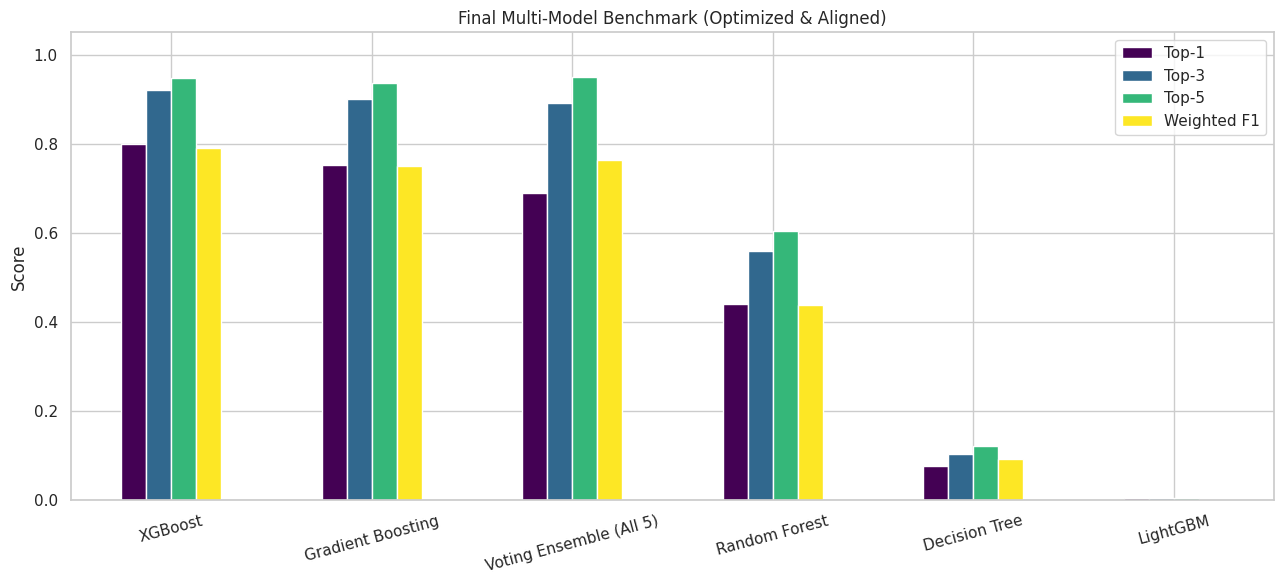

In [ ]:
results = {}

def evaluate(name, y_proba):
    y_pred = np.argmax(y_proba, axis=1)
    top1 = accuracy_score(y_test, y_pred)

    try:
        top3 = top_k_accuracy_score(y_test, y_proba, k=3, labels=np.arange(new_num_classes))
        top5 = top_k_accuracy_score(y_test, y_proba, k=5, labels=np.arange(new_num_classes))
    except ValueError:
        top3, top5 = 0.0, 0.0

    f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results[name] = {'Top-1': top1, 'Top-3': top3, 'Top-5': top5, 'Weighted F1': f1w}

# --- Extract Probabilities ---
xgb_proba = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration + 1))
lgbm_proba = lgbm_model.predict_proba(X_test)
gb_proba   = gb_model.predict_proba(X_test)
rf_proba   = rf_model.predict_proba(X_test)
dt_proba   = dt_model.predict_proba(X_test)

# --- Evaluate Individual Models ---
evaluate('XGBoost', xgb_proba)
evaluate('LightGBM', lgbm_proba)
evaluate('Gradient Boosting', gb_proba)
evaluate('Random Forest', rf_proba)
evaluate('Decision Tree', dt_proba)

# --- Evaluate Voting Ensemble ---
ensemble_proba = (xgb_proba + lgbm_proba + gb_proba + rf_proba + dt_proba) / 5.0
evaluate('Voting Ensemble (All 5)', ensemble_proba)

# --- Display & Plot ---
comparison_df = pd.DataFrame(results).T.sort_values('Top-1', ascending=False)
print("\n--- Final Model Leaderboard ---")
print(comparison_df.round(4))

comparison_df.plot(kind='bar', figsize=(13, 6), colormap='viridis')
plt.title('Final Multi-Model Benchmark (Optimized & Aligned)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


--- Final Model Leaderboard ---
                            Top-1   Top-3   Top-5  Weighted F1
XGBoost                    0.7992  0.9204  0.9483       0.7905
Power Ensemble (XGB + GB)  0.7793  0.9287  0.9605       0.7744
Gradient Boosting          0.7531  0.9001  0.9372       0.7502
Voting Ensemble (All 5)    0.6891  0.8909  0.9493       0.7632
Random Forest              0.4401  0.5598  0.6034       0.4383
Decision Tree              0.0777  0.1038  0.1223       0.0925
LightGBM                   0.0044  0.0059  0.0060       0.0000


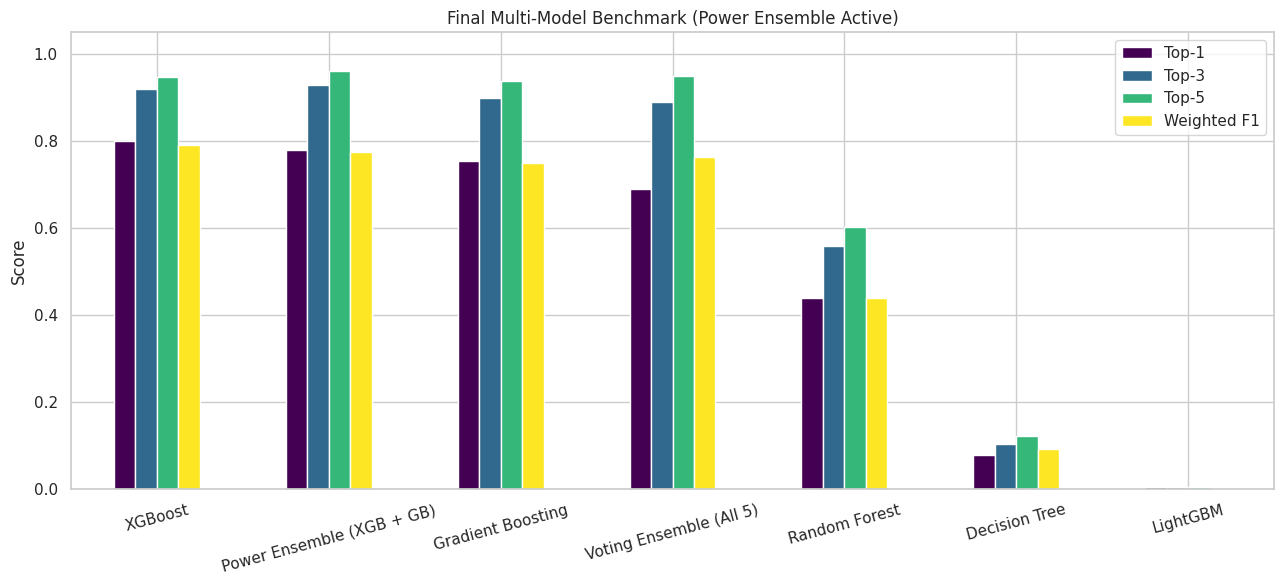

In [ ]:
# --- Power Ensemble (Top 2 Models Only) ---
# We are dropping LightGBM, Decision Tree, and Random Forest
# # because they are actively dragging down the average.

power_ensemble_proba = (xgb_proba + gb_proba) / 2.0
evaluate('Power Ensemble (XGB + GB)', power_ensemble_proba)

# --- Generate Final Output ---
comparison_df = pd.DataFrame(results).T.sort_values('Top-1', ascending=False)
print("\n--- Final Model Leaderboard ---")
print(comparison_df.round(4))

comparison_df.plot(kind='bar', figsize=(13, 6), colormap='viridis')
plt.title('Final Multi-Model Benchmark (Power Ensemble Active)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()